# 프로젝트 모델의 PyTorch·Triton 실제 추론 비교

실측 JSON과 재현 가능한 모델·벤치마크 source를 내장한 노트북입니다. 기본 실행은 GPU 없이 결과를 재분석합니다. NumPy와 Matplotlib이 필요하며 Colab 기본 환경에서 사용할 수 있습니다.

PyTorch는 컴파일 버전, native Triton은 GPU 계산 전체를 수동 Triton kernel로 수행합니다. 하드웨어별 최적화의 제한과 미수행 후보를 결과와 함께 기록했습니다.

In [1]:
# 기본 실행은 저장된 실측 결과만 재분석합니다. GPU를 사용하려면 True로 바꾸세요.
RUN_BENCHMARK = False
import base64, gzip, hashlib, json, sys
from pathlib import Path
PAYLOAD = '...'
compressed = base64.b64decode(PAYLOAD)
assert hashlib.sha256(compressed).hexdigest() == '69a5f32cc75e7251c9f0dadcaafcbdbb55598369547bcee5dc0a9fcf2367cb23'
archive = json.loads(gzip.decompress(compressed))
base = Path('/content') if Path('/content').exists() else Path.cwd()
REPRO_ROOT = base / 'tensor2silicon_benchmark_reproduction'
for relative, source in archive['sources'].items():
    target = REPRO_ROOT / relative
    assert target.resolve().is_relative_to(REPRO_ROOT.resolve())
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source)
RESULTS_DIR = REPRO_ROOT / 'llm_bench' / 'results' / 'embedded-final'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
for name, data in archive['runs'].items():
    (RESULTS_DIR / (name + '.json')).write_text(json.dumps(data, ensure_ascii=False, indent=2))
for name, data in archive['sidecars'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_bytes(base64.b64decode(archive['sidecars_raw'][name]))
for name, data in archive['candidates'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_text(json.dumps(data, ensure_ascii=False, indent=2))
for name, data in archive['torch_candidates'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_text(json.dumps(data, ensure_ascii=False, indent=2))
for name, data in archive['native_candidates'].items():
    assert Path(name).name == name
    (RESULTS_DIR / name).write_text(json.dumps(data, ensure_ascii=False, indent=2))
sys.path.insert(0, str(REPRO_ROOT))
runs = list(archive['runs'].items())
print('복원 위치:', REPRO_ROOT)
source_mismatches = {}
for name, data in runs:
    env = data['environment']
    print(name, env['gpu'], 'PyTorch', env['torch'], 'Triton', env['triton'], 'CUDA', env['cuda'])
    configured = data.get('arguments', {}).get('tuning_config')
    if configured and data.get('tuning_config_sha256'):
        actual_hash = hashlib.sha256((RESULTS_DIR / Path(configured).name).read_bytes()).hexdigest()
        assert actual_hash == data['tuning_config_sha256'], 'Tuning config SHA-256 mismatch'
    source_mismatches[name] = [path for path, digest in env.get('source_sha256', {}).items()
                               if path != 'llm_bench/report.py' and
                               (path not in archive['sources'] or
                                hashlib.sha256(archive['sources'][path].encode()).hexdigest() != digest)]
    print('측정 때의 compute source와 다른 파일:', source_mismatches[name])


복원 위치: /content/tensor2silicon_benchmark_reproduction
final-run1 NVIDIA RTX PRO 6000 Blackwell Server Edition PyTorch 2.11.0+cu130 Triton 3.6.0 CUDA 13.0
측정 때의 compute source와 다른 파일: []
final-run2 NVIDIA RTX PRO 6000 Blackwell Server Edition PyTorch 2.11.0+cu130 Triton 3.6.0 CUDA 13.0
측정 때의 compute source와 다른 파일: []


## 선택: GPU 재측정

기본값은 저장 결과 분석입니다. 재측정하려면 위 cell의 `RUN_BENCHMARK=True`로 바꿉니다. 기록된 GPU/소프트웨어 환경과 현재 런타임을 비교하세요. 컴파일·autotune·정확성 검증은 steady-state 측정 전에 수행됩니다.

In [2]:
# GPU 재측정은 최대 수십 분 이상 걸릴 수 있습니다. 모델/패키지 다운로드는 하지 않습니다.
if RUN_BENCHMARK:
    import os, subprocess, torch, triton
    assert torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    assert not any(source_mismatches.values()), '기록된 source와 다른 파일을 먼저 확인하세요.'
    print('재측정 GPU:', torch.cuda.get_device_name(), 'torch:', torch.__version__, 'triton:', triton.__version__)
    refreshed = []
    for name, saved in runs:
        args = saved['arguments']
        output = RESULTS_DIR / (name + '-rerun.json')
        command = [sys.executable, '-m', 'llm_bench', '--backend', 'all', '--preset', args.get('preset', 'colab'),
                   '--workload', 'all', '--seed', str(args.get('seed', 123)), '--profile', '--out', str(output)]
        if args.get('reverse'):
            command.append('--reverse')
        if args.get('hybrid_attention'):
            command += ['--hybrid-attention', args['hybrid_attention']]
        if args.get('hybrid_matmul'):
            command += ['--hybrid-matmul', args['hybrid_matmul']]
        if args.get('torch_attention'):
            command += ['--torch-attention', args['torch_attention']]
        if args.get('tuning_config'):
            tuning_config = RESULTS_DIR / Path(args['tuning_config']).name
            assert tuning_config.exists()
            command += ['--tuning-config', str(tuning_config)]
        subprocess.run(command, cwd=REPRO_ROOT, check=True)
        refreshed.append((name + '-rerun', json.loads(output.read_text())))
    runs = refreshed
else:
    print('저장된 실제 측정 결과를 사용합니다. RUN_BENCHMARK=False')


저장된 실제 측정 결과를 사용합니다. RUN_BENCHMARK=False


In [3]:
from llm_bench.report import records_from_runs, render_report, plot_records
from IPython.display import Markdown, display, Image
records = records_from_runs(runs)
display(Markdown(render_report(runs, records, archive['inventory'], archive['sidecars'],
                              list(archive['candidates'].items()), str(RESULTS_DIR),
                              list(archive['torch_candidates'].items()), list(archive['native_candidates'].items()))))


# PyTorch·Triton 실제 추론 비교

- **prefill GPU 중앙값 최저** — final-run1: PyTorch + Triton compile 6.812 ms; final-run2: PyTorch + Triton compile 6.825 ms.
- **decode 한 step GPU 중앙값 최저** — final-run1: PyTorch + Triton compile 1.528 ms; final-run2: PyTorch + Triton compile 1.527 ms.
- **128-token 생성 GPU 중앙값 최저** — final-run1: Native Triton 125.959 ms; final-run2: Native Triton 126.011 ms.

각 실행의 중앙값을 따로 비교했다. 두 실행의 원시 표본을 합치지 않았으며, 아래 배속은 모두 같은 실행의 PyTorch compile 대비 값이다.

**중앙값 차이가 1% 미만인 조건은 거의 동급으로 해석한다.** 작은 순위 차이만으로 의미 있는 우위를 주장하지 않으며 통계적 동등성 검정을 수행한 것은 아니다.

- final-run1 prefill: PyTorch + Triton compile와 PyTorch compile 차이 0.58%.
- final-run1 128-token 생성: PyTorch + Triton 126.105 ms와 Native Triton 125.959 ms, 차이 0.12%.
- final-run2 prefill: PyTorch + Triton compile와 PyTorch compile 차이 0.83%.
- final-run2 128-token 생성: PyTorch + Triton 126.112 ms와 Native Triton 126.011 ms, 차이 0.08%.

## 모델과 측정 조건

기존 `llm_roofline` decoder를 사용했다: 8 layers, D=2048, F=5632, query/KV heads=16/16, head_dim=128, vocab=32000. Affine LayerNorm(ε=1e-5), split-half RoPE, causal attention, SwiGLU, residual, LM head를 모두 실행한다. 학습된 언어 모델 checkpoint가 아닌 프로젝트의 고정 seed 합성 가중치이므로 생성 토큰의 언어 품질을 평가하지 않는다.

| 실행 | 실제 원본 parameter 수 | 백만 parameter |
| --- | --- | --- |
| final-run1 | 542,183,424 | 542.183 M |
| final-run2 | 542,183,424 | 542.183 M |

Parameter 수는 실제 생성한 원본 가중치 tensor에서 합산했다. 실행용 packing으로 추가한 복사본은 별도 모델 parameter로 세지 않았다.

| 실행 | GPU | Compute capability | VRAM GiB | PyTorch | Triton | CUDA |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | NVIDIA RTX PRO 6000 Blackwell Server Edition | 12/0 | 95.0 | 2.11.0+cu130 | 3.6.0 | 13.0 |
| final-run2 | NVIDIA RTX PRO 6000 Blackwell Server Edition | 12/0 | 95.0 | 2.11.0+cu130 | 3.6.0 | 13.0 |

BF16 저장·출력, FP32 GEMM 누산 및 normalization/RoPE/SwiGLU 중간 계산을 사용했다. 동일한 BF16 반올림 가중치를 FP32로 변환해 기존 독립 모델과 검증했고 TF32와 BF16 reduced-precision reduction을 껐다. PyTorch 두 경로는 `fullgraph=True`, `dynamic=False`, `max-autotune-no-cudagraphs`로 컴파일한 뒤 세 경로 모두 같은 수동 CUDA Graph 실행 조건을 적용한다. CUDA Graph 없는 측정도 별도로 보존했다.

순수 PyTorch 기준선도 추론용 attention 경로를 사용한다. `--torch-attention flex-decode`는 연속 생성에서 공식 `torch.nn.attention.flex_attention`을 컴파일하고, GPU 위치 tensor를 참조하는 `score_mod`로 미래 cache 슬롯을 제외한다. 이는 사용자 작성 Triton kernel이 없는 PyTorch 경로다. 짧은 query에서 decoding 전용 kernel로 내리는 동작과 tensor 위치 closure는 [PyTorch 공식 문서](https://pytorch.org/blog/flexattention-for-inference/)에 설명되어 있다. 고정 B=8 decode의 SDPA는 전체 KV가 유효하므로 `attn_mask=None`, `is_causal=False`를 사용한다.

| 조건 | Batch | 입력/query 길이 | KV 길이 | 생성 토큰 |
| --- | --- | --- | --- | --- |
| prefill | 1 | 2048 | 2048 | — |
| decode | 8 | 1 | 2048 | — |
| generate | 1 | 2048 | prompt부터 증가 | 128 |

Prefill은 **모든 prompt 위치의 logits**를 계산한다. 마지막 prompt 위치의 logits만 계산하도록 LM head를 줄이는 production 최적화는 이번 비교 범위 밖이다. 생성의 첫 prefill도 같은 계산을 수행한다.

고정 decode는 같은 KV 길이에서 한 토큰을 처리하는 지연이다. 생성 측정은 GPU에서 greedy argmax로 다음 토큰을 선택하고 KV cache와 위치를 갱신하는 실제 연속 실행이다. 토큰화, 네트워크, queueing, 모델 로딩, 컴파일, autotune, Graph capture는 steady-state 시간에 포함하지 않는다. 생성 시간에는 prefill·cache 복사·첫 토큰 선택과 이후 decode가 포함된다.

## 실제 시간

| 실행 | 구현 | 조건 | GPU median ms | GPU p95 ms | Wall median ms | Wall p95 ms | GPU 배속 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 6.851 | 6.856 | 6.861 | 6.869 | 1.000× |
| final-run1 | PyTorch compile | decode | 1.545 | 1.545 | 1.578 | 1.582 | 1.000× |
| final-run1 | PyTorch compile | generate | 158.339 | 158.352 | 158.354 | 158.367 | 1.000× |
| final-run1 | PyTorch + Triton compile | prefill | 6.812 | 6.815 | 6.847 | 6.854 | 1.006× |
| final-run1 | PyTorch + Triton compile | decode | 1.528 | 1.528 | 1.558 | 1.561 | 1.011× |
| final-run1 | PyTorch + Triton compile | generate | 126.105 | 126.123 | 126.119 | 126.137 | 1.256× |
| final-run1 | Native Triton | prefill | 7.030 | 7.033 | 7.063 | 7.073 | 0.975× |
| final-run1 | Native Triton | decode | 1.577 | 1.578 | 1.616 | 1.620 | 0.979× |
| final-run1 | Native Triton | generate | 125.959 | 125.984 | 125.974 | 126.000 | 1.257× |
| final-run2 | Native Triton | prefill | 7.015 | 7.020 | 7.025 | 7.034 | 0.981× |
| final-run2 | Native Triton | decode | 1.574 | 1.574 | 1.612 | 1.615 | 0.982× |
| final-run2 | Native Triton | generate | 126.011 | 126.022 | 126.026 | 126.036 | 1.259× |
| final-run2 | PyTorch + Triton compile | prefill | 6.825 | 6.828 | 6.858 | 6.866 | 1.008× |
| final-run2 | PyTorch + Triton compile | decode | 1.527 | 1.527 | 1.558 | 1.561 | 1.012× |
| final-run2 | PyTorch + Triton compile | generate | 126.112 | 126.143 | 126.126 | 126.158 | 1.258× |
| final-run2 | PyTorch compile | prefill | 6.881 | 6.888 | 6.921 | 6.928 | 1.000× |
| final-run2 | PyTorch compile | decode | 1.545 | 1.545 | 1.579 | 1.582 | 1.000× |
| final-run2 | PyTorch compile | generate | 158.616 | 158.632 | 158.631 | 158.647 | 1.000× |

고정 prefill/decode의 GPU 표본은 연속 호출을 CUDA event로 잰 **round 평균**이며 p95도 round 평균들의 p95다. Wall 표본은 호출마다 CUDA 완료를 동기화한 지연이다. 생성의 GPU/wall 표본은 각각 한 번의 전체 생성 실행이다. GPU 값과 wall 값을 같은 분포로 해석하지 않는다.

| 실행 | 구현 | GPU TTFT ms | GPU decode ms/token | Decode 배속 |
| --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | 7.117 | 1.191 | 1.000× |
| final-run1 | PyTorch + Triton compile | 7.035 | 0.938 | 1.270× |
| final-run1 | Native Triton | 7.244 | 0.935 | 1.274× |
| final-run2 | PyTorch compile | 7.150 | 1.193 | 1.000× |
| final-run2 | PyTorch + Triton compile | 7.047 | 0.938 | 1.272× |
| final-run2 | Native Triton | 7.233 | 0.935 | 1.275× |

TTFT는 prefill·cache 복사·첫 argmax를 포함한다. Decode ms/token은 첫 토큰 이후 전체 decode GPU 시간의 토큰당 평균이며, 매 토큰 지연 분포의 p95를 의미하지 않는다.

| 실행 | PyTorch 대비 비교 경로 | 전체 생성 시간 차이 ms | TTFT 차이 ms | TPOT 차이 ms/token × decode 횟수 |
| --- | --- | --- | --- | --- |
| final-run1 | PyTorch + Triton compile | +32.234 | +0.081 | +0.25318 × 127 = +32.154 |
| final-run1 | Native Triton | +32.380 | -0.127 | +0.25594 × 127 = +32.505 |
| final-run2 | PyTorch + Triton compile | +32.504 | +0.103 | +0.25514 × 127 = +32.402 |
| final-run2 | Native Triton | +32.605 | -0.083 | +0.25740 × 127 = +32.690 |

차이는 모두 `PyTorch 시간 − 비교 경로 시간`으로 계산해 양수이면 비교 경로가 빠르다. 전체·TTFT·TPOT의 중앙값을 각각 사용하므로 열 사이의 합은 전체 차이와 정확히 일치하지 않을 수 있다.

전체 생성 시간 차이는 다음 조건에서 주로 **B=1 연속 decode 구간**에 나타났다: final-run1 PyTorch + Triton compile; final-run1 Native Triton; final-run2 PyTorch + Triton compile; final-run2 Native Triton. 위 `TPOT 차이 × 127`이 그 크기를 보여준다. 이는 측정 구간의 분해이며 특정 attention kernel만의 인과적 효과는 아니다. GEMM 선택과 compiler fusion 경계도 함께 달라질 수 있다.

## 정확성 및 준비 비용

| 실행 | 구현 | 조건 | 검증 tensor 수 | 최대 NRMSE | 최대 normalized max |
| --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 34 | 0.00766 | 0.05190 |
| final-run1 | PyTorch compile | decode | 34 | 0.00807 | 0.03989 |
| final-run1 | PyTorch compile | generate | 153 | 0.00763 | 0.04417 |
| final-run1 | PyTorch + Triton compile | prefill | 34 | 0.01064 | 0.06523 |
| final-run1 | PyTorch + Triton compile | decode | 34 | 0.01132 | 0.05702 |
| final-run1 | PyTorch + Triton compile | generate | 153 | 0.01072 | 0.06532 |
| final-run1 | Native Triton | prefill | 34 | 0.01064 | 0.06523 |
| final-run1 | Native Triton | decode | 34 | 0.01133 | 0.05595 |
| final-run1 | Native Triton | generate | 153 | 0.01084 | 0.06532 |
| final-run2 | Native Triton | prefill | 34 | 0.01051 | 0.06035 |
| final-run2 | Native Triton | decode | 34 | 0.01144 | 0.05186 |
| final-run2 | Native Triton | generate | 153 | 0.01061 | 0.06003 |
| final-run2 | PyTorch + Triton compile | prefill | 34 | 0.01051 | 0.06035 |
| final-run2 | PyTorch + Triton compile | decode | 34 | 0.01136 | 0.05666 |
| final-run2 | PyTorch + Triton compile | generate | 153 | 0.01109 | 0.06003 |
| final-run2 | PyTorch compile | prefill | 34 | 0.00756 | 0.04741 |
| final-run2 | PyTorch compile | decode | 34 | 0.00828 | 0.04035 |
| final-run2 | PyTorch compile | generate | 153 | 0.00757 | 0.04513 |

합격 기준은 NRMSE ≤ 0.02, 최대 절대 오차 / reference RMS ≤ 0.20이다. 생성 검증은 같은 FP32 reference 토큰을 입력하는 teacher forcing으로 127회 decode를 진행하고, 0부터 센 step 0·1·7·31·63·126의 여섯 checkpoint에서 logits와 유효 KV의 누적 오차를 확인한다. 측정 전 캡처된 decode Graph를 두 번 연속 replay해, 갱신된 token·KV·GPU 위치를 사용하는 출력도 FP32 reference와 검증한다. 위 최대 오차와 검증 tensor 수에는 이 Graph replay 검사도 포함된다. 실제 greedy 생성은 각 경로의 출력을 사용하므로 BF16 오차와 가까운 logit 순위 때문에 토큰열이 달라질 수 있다. 이 결과를 bitwise 동등성이나 언어 품질 동등성으로 해석하지 않는다.

| 실행 | Greedy token열 비교 | 동일 위치 일치 | 일치율 | 공통 prefix 길이 | 첫 차이 위치(1부터) |
| --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile / PyTorch + Triton compile | 24/128 | 18.8% | 24 | 25 |
| final-run1 | PyTorch compile / Native Triton | 20/128 | 15.6% | 20 | 21 |
| final-run1 | PyTorch + Triton compile / Native Triton | 20/128 | 15.6% | 20 | 21 |
| final-run2 | PyTorch compile / PyTorch + Triton compile | 74/128 | 57.8% | 74 | 75 |
| final-run2 | PyTorch compile / Native Triton | 74/128 | 57.8% | 74 | 75 |
| final-run2 | PyTorch + Triton compile / Native Triton | 111/128 | 86.7% | 111 | 112 |

이 표는 각 구현이 독립적으로 생성한 token열의 진단값이다. 첫 차이 이후에는 서로 다른 토큰을 입력하므로 이후 불일치는 같은 입력에 대한 수치 오차를 뜻하지 않는다. 일치율은 정확성 합격 기준이나 언어 품질 지표가 아니다.

| 실행 | 구현 | 조건 | 모델 준비 s | 첫 실행/검증 구간 s | 구간 의미 |
| --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 0.530 | 1.547 | 첫 호출 compile/autotune 포함 |
| final-run1 | PyTorch compile | decode | 0.008 | 1.902 | 첫 호출 compile/autotune 포함 |
| final-run1 | PyTorch compile | generate | 0.008 | 5.799 | compile+autotune+reference 검증 |
| final-run1 | PyTorch + Triton compile | prefill | 0.190 | 0.350 | 첫 호출 compile/autotune 포함 |
| final-run1 | PyTorch + Triton compile | decode | 0.008 | 0.319 | 첫 호출 compile/autotune 포함 |
| final-run1 | PyTorch + Triton compile | generate | 0.008 | 4.349 | compile+autotune+reference 검증 |
| final-run1 | Native Triton | prefill | 0.004 | 10.798 | 첫 호출 compile/autotune 포함 |
| final-run1 | Native Triton | decode | 0.004 | 6.344 | 첫 호출 compile/autotune 포함 |
| final-run1 | Native Triton | generate | 0.004 | 7.062 | compile+autotune+reference 검증 |
| final-run2 | Native Triton | prefill | 0.571 | 5.377 | 첫 호출 compile/autotune 포함 |
| final-run2 | Native Triton | decode | 0.004 | 3.593 | 첫 호출 compile/autotune 포함 |
| final-run2 | Native Triton | generate | 0.004 | 4.311 | compile+autotune+reference 검증 |
| final-run2 | PyTorch + Triton compile | prefill | 0.147 | 0.793 | 첫 호출 compile/autotune 포함 |
| final-run2 | PyTorch + Triton compile | decode | 0.008 | 0.344 | 첫 호출 compile/autotune 포함 |
| final-run2 | PyTorch + Triton compile | generate | 0.008 | 1.654 | compile+autotune+reference 검증 |
| final-run2 | PyTorch compile | prefill | 0.008 | 0.904 | 첫 호출 compile/autotune 포함 |
| final-run2 | PyTorch compile | decode | 0.008 | 1.032 | 첫 호출 compile/autotune 포함 |
| final-run2 | PyTorch compile | generate | 0.008 | 5.390 | compile+autotune+reference 검증 |

첫 호출 비용은 프로세스·디스크 compiler cache 상태에 영향을 받는다. 별도 cache 제거를 수행한 cold-start 배포 비용으로 주장하지 않는다.

| 실행 | 구현 | 조건 | Peak allocated GiB | Peak reserved GiB |
| --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 3.834 | 5.658 |
| final-run1 | PyTorch compile | decode | 4.711 | 7.293 |
| final-run1 | PyTorch compile | generate | 4.041 | 4.871 |
| final-run1 | PyTorch + Triton compile | prefill | 3.850 | 5.697 |
| final-run1 | PyTorch + Triton compile | decode | 4.727 | 7.336 |
| final-run1 | PyTorch + Triton compile | generate | 4.057 | 4.941 |
| final-run1 | Native Triton | prefill | 3.858 | 5.758 |
| final-run1 | Native Triton | decode | 4.735 | 7.373 |
| final-run1 | Native Triton | generate | 4.057 | 4.973 |
| final-run2 | Native Triton | prefill | 3.818 | 5.715 |
| final-run2 | Native Triton | decode | 4.695 | 7.311 |
| final-run2 | Native Triton | generate | 4.017 | 4.836 |
| final-run2 | PyTorch + Triton compile | prefill | 3.834 | 5.656 |
| final-run2 | PyTorch + Triton compile | decode | 4.711 | 7.332 |
| final-run2 | PyTorch + Triton compile | generate | 4.041 | 4.863 |
| final-run2 | PyTorch compile | prefill | 3.850 | 5.697 |
| final-run2 | PyTorch compile | decode | 4.727 | 7.371 |
| final-run2 | PyTorch compile | generate | 4.057 | 4.875 |

메모리는 해당 steady 측정 구간의 PyTorch CUDA allocator peak이며 실행 중인 프로세스 전체를 포함한다. BF16 원본·packed 가중치, **정확성 검증용 FP32 reference 가중치**, KV cache, CUDA Graph pool과 workspace가 포함되므로 제품 배포 시 모델만의 최소 VRAM이나 GPU 전체 사용량으로 해석하지 않는다. Reserved는 allocator가 보유한 용량이다.

## CUDA Graph 효과와 실행 커널

| 실행 | 구현 | 조건 | Graph GPU ms | Graph 없는 GPU ms | Graph 배속 |
| --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 6.851 | 7.019 | 1.024× |
| final-run1 | PyTorch compile | decode | 1.545 | 1.695 | 1.097× |
| final-run1 | PyTorch + Triton compile | prefill | 6.812 | 6.937 | 1.018× |
| final-run1 | PyTorch + Triton compile | decode | 1.528 | 1.663 | 1.089× |
| final-run1 | Native Triton | prefill | 7.030 | 7.163 | 1.019× |
| final-run1 | Native Triton | decode | 1.577 | 2.094 | 1.328× |
| final-run2 | PyTorch compile | prefill | 6.881 | 7.026 | 1.021× |
| final-run2 | PyTorch compile | decode | 1.545 | 1.696 | 1.098× |
| final-run2 | PyTorch + Triton compile | prefill | 6.825 | 6.933 | 1.016× |
| final-run2 | PyTorch + Triton compile | decode | 1.527 | 1.663 | 1.089× |
| final-run2 | Native Triton | prefill | 7.015 | 7.143 | 1.018× |
| final-run2 | Native Triton | decode | 1.574 | 2.003 | 1.273× |

| 실행 | 구현 | 조건 | CUDA event 수 | Native kernel 출처 | 시간 상위 kernel |
| --- | --- | --- | --- | --- | --- |
| final-run1 | PyTorch compile | prefill | 90 | — | `void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_256x128_32x3_nn_align8>(cut`; `triton_tem_fused__to_copy__unsafe_view_mm_mul_silu_split_view_7`; `triton_tem_fused__unsafe_view_add_embedding_mm_native_layer_norm_view_9` |
| final-run1 | PyTorch compile | decode | 90 | — | `void pytorch_flash::flash_fwd_splitkv_kernel<Flash_fwd_kernel_traits<128, 64, 128, 4, false, fa`; `triton_tem_fused__unsafe_view_add_embedding_mm_native_layer_norm_view_6`; `triton_tem_fused_embedding_mm_native_layer_norm_view_1` |
| final-run1 | PyTorch compile | generate | 125 | — | `triton_tem_fused__to_copy_flex_attention_ones_slice_sort_sum_transpose_zeros_7`; `triton_red_fused__unsafe_view_add_embedding_mm_native_layer_norm_view_11`; `triton_red_fused__to_copy__unsafe_view_mm_mul_silu_split_view_13` |
| final-run1 | PyTorch + Triton compile | prefill | 75 | — | `void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_256x128_32x3_nn_align8>(cut`; `triton_tem_fused_mm_view_0`; `triton_tem_fused_mm_view_2` |
| final-run1 | PyTorch + Triton compile | decode | 83 | — | `_decode_parts`; `triton_tem_fused_mm_view_2`; `triton_tem_fused_mm_view_0` |
| final-run1 | PyTorch + Triton compile | generate | 110 | — | `_small_gemm`; `_decode_parts`; `_add_layernorm` |
| final-run1 | Native Triton | prefill | 75 | 검증 통과 | `_gemm`; `_tma_gemm`; `_prefill` |
| final-run1 | Native Triton | decode | 107 | 검증 통과 | `_decode_parts`; `_small_gemm`; `_add_layernorm` |
| final-run1 | Native Triton | generate | 110 | 검증 통과 | `_small_gemm`; `_decode_parts`; `_add_layernorm` |
| final-run2 | Native Triton | prefill | 75 | 검증 통과 | `_gemm`; `_tma_gemm`; `_prefill` |
| final-run2 | Native Triton | decode | 107 | 검증 통과 | `_decode_parts`; `_small_gemm`; `_add_layernorm` |
| final-run2 | Native Triton | generate | 110 | 검증 통과 | `_small_gemm`; `_decode_parts`; `_add_layernorm` |
| final-run2 | PyTorch + Triton compile | prefill | 75 | — | `void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_256x128_32x3_nn_align8>(cut`; `triton_tem_fused_mm_view_0`; `triton_tem_fused_mm_view_2` |
| final-run2 | PyTorch + Triton compile | decode | 83 | — | `_decode_parts`; `triton_tem_fused_mm_view_2`; `triton_tem_fused_mm_view_0` |
| final-run2 | PyTorch + Triton compile | generate | 110 | — | `_small_gemm`; `_decode_parts`; `_add_layernorm` |
| final-run2 | PyTorch compile | prefill | 90 | — | `void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_256x128_32x3_nn_align8>(cut`; `triton_tem_fused__to_copy__unsafe_view_mm_mul_silu_split_view_7`; `triton_tem_fused__unsafe_view_add_embedding_mm_native_layer_norm_view_9` |
| final-run2 | PyTorch compile | decode | 90 | — | `void pytorch_flash::flash_fwd_splitkv_kernel<Flash_fwd_kernel_traits<128, 64, 128, 4, false, fa`; `triton_tem_fused__unsafe_view_add_embedding_mm_native_layer_norm_view_6`; `triton_tem_fused_embedding_mm_native_layer_norm_view_1` |
| final-run2 | PyTorch compile | generate | 125 | — | `triton_tem_fused__to_copy_flex_attention_ones_slice_sort_sum_transpose_zeros_7`; `triton_red_fused__unsafe_view_add_embedding_mm_native_layer_norm_view_11`; `triton_red_fused__to_copy__unsafe_view_mm_mul_silu_split_view_13` |

Profiler는 steady timing과 분리한 일반 forward/decode를 관찰했다. Chrome trace의 leaf `kernel`, `gpu_memcpy`, `gpu_memset` event만 집계해 compiled-region annotation과 자식 kernel 시간을 중복 계산하지 않는다. Native 경로는 프로젝트 Triton kernel 이름의 allowlist와 memcpy/memset만 허용하며 알 수 없는 CUDA kernel이 있으면 실패한다. CPU 쪽 ATen allocation/metadata 이벤트만으로 library compute를 판단하지 않는다. 전체 kernel 이름과 시간은 final JSON, Chrome trace는 옆의 trace 파일에 보존했다.

## 최적화 범위와 결과 해석

| 경로 | 실제 구현/탐색 |
| --- | --- |
| 공통 | 고정 shape, BF16, 사전 QKV·gate/up weight packing, precomputed FP32 RoPE, static KV cache, CUDA Graph, 워밍업 후 측정 |
| PyTorch compile | final-run1: prefill 및 전체 KV가 유효한 고정 decode는 SDPA; 연속 생성 decode는 공식 PyTorch FlexAttention; final-run2: prefill 및 전체 KV가 유효한 고정 decode는 SDPA; 연속 생성 decode는 공식 PyTorch FlexAttention. Inductor max-autotune와 compiler fusion; 내부 생성 Triton 및 vendor GEMM 허용 |
| PyTorch + Triton | final-run1: M=1 decode projection/LM head만 Triton GEMM; B=8 decode와 prefill은 PyTorch GEMM, prefill/decode Triton attention; final-run2: M=1 decode projection/LM head만 Triton GEMM; B=8 decode와 prefill은 PyTorch GEMM, prefill/decode Triton attention. 공통 수동 Triton embedding, affine LN, residual+LN, RoPE+KV write, SwiGLU, argmax |
| Native Triton | 모든 model compute를 Triton으로 실행. grouped tiled/persistent GEMM 및 선택 shape의 TMA 후보, small-M split-K, 타일·warps·stages autotune, causal online-softmax prefill, split-KV decode 및 작은 연산 fusion |

- `final-run1` 인자: `{"backend": "all", "flex_kernel_options": {"ROWS_GUARANTEED_SAFE": true, "SPLIT_KV": 1}, "hybrid_attention": "triton", "hybrid_matmul": "m1-triton", "no_compile": false, "out": "/content/llm_bench_work/results/final-run1.json", "preset": "colab", "profile": true, "quick": false, "reverse": false, "seed": 123, "torch_attention": "flex-decode", "tuning_config": "/content/llm_bench_work/results/tuning-final.json", "workload": "all"}`
- `final-run2` 인자: `{"backend": "all", "flex_kernel_options": {"ROWS_GUARANTEED_SAFE": true, "SPLIT_KV": 1}, "hybrid_attention": "triton", "hybrid_matmul": "m1-triton", "no_compile": false, "out": "/content/llm_bench_work/results/final-run2.json", "preset": "colab", "profile": true, "quick": false, "reverse": true, "seed": 321, "torch_attention": "flex-decode", "tuning_config": "/content/llm_bench_work/results/tuning-final.json", "workload": "all"}`

| 실행 | 선택 config | GEMM M,K,N | 측정 후 선택 split-K | 개별 GEMM μs | Cache 조건 |
| --- | --- | --- | --- | --- | --- |
| final-run1 | tuning-final.json | 1,2048,2048 | 4 | 18.432 | cold |
| final-run1 | tuning-final.json | 1,2048,6144 | 16 | 34.816 | cold |
| final-run1 | tuning-final.json | 1,2048,11264 | 1 | 52.512 | cold |
| final-run1 | tuning-final.json | 1,2048,32000 | 1 | 127.984 | cold |
| final-run1 | tuning-final.json | 1,5632,2048 | 8 | 34.288 | cold |
| final-run1 | tuning-final.json | 8,2048,2048 | 8 | 19.360 | cold |
| final-run1 | tuning-final.json | 8,2048,6144 | 16 | 35.584 | cold |
| final-run1 | tuning-final.json | 8,2048,11264 | 1 | 53.248 | cold |
| final-run1 | tuning-final.json | 8,2048,32000 | 1 | 128.992 | cold |
| final-run1 | tuning-final.json | 8,5632,2048 | 8 | 34.784 | cold |
| final-run2 | tuning-final.json | 1,2048,2048 | 4 | 18.432 | cold |
| final-run2 | tuning-final.json | 1,2048,6144 | 16 | 34.816 | cold |
| final-run2 | tuning-final.json | 1,2048,11264 | 1 | 52.512 | cold |
| final-run2 | tuning-final.json | 1,2048,32000 | 1 | 127.984 | cold |
| final-run2 | tuning-final.json | 1,5632,2048 | 8 | 34.288 | cold |
| final-run2 | tuning-final.json | 8,2048,2048 | 8 | 19.360 | cold |
| final-run2 | tuning-final.json | 8,2048,6144 | 16 | 35.584 | cold |
| final-run2 | tuning-final.json | 8,2048,11264 | 1 | 53.248 | cold |
| final-run2 | tuning-final.json | 8,2048,32000 | 1 | 128.992 | cold |
| final-run2 | tuning-final.json | 8,5632,2048 | 8 | 34.784 | cold |

Split-K는 각 shape의 후보를 측정해 선택한 factor다. 개별 GEMM의 후보 선택 시간은 전체 모델 추론 시간과 다른 실험이며 합산하지 않았다. Cold cache 모드이면 cache flush는 후보 시간 바깥에서 실행됐다.

| 실행 | 선택 config | Attention B,NQ,NK,S,H | 측정 위치 | 선택 split-KV | 위치별 중앙값의 평균 μs | Cache 조건 |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | tuning-final.json | 1,16,16,2176,128 | 2048, 2174 | 32 | 31.440 | cold |
| final-run1 | tuning-final.json | 8,16,16,2048,128 | 2047 | 16 | 135.056 | cold |
| final-run2 | tuning-final.json | 1,16,16,2176,128 | 2048, 2174 | 32 | 31.440 | cold |
| final-run2 | tuning-final.json | 8,16,16,2048,128 | 2047 | 16 | 135.056 | cold |

Native split-KV는 각 shape의 측정 위치들에서 얻은 중앙값의 산술 평균이 가장 작은 factor를 선택한다. Attention 부분 결과를 합치는 reduction까지 포함한 구성요소 시간이며 전체 모델 시간에 합산하지 않았다. 후보 간 차이가 1% 안팎이면 측정 변동 수준일 수 있으며, 선택된 순위만으로 유의한 성능 향상을 주장하지 않는다.

| 실행 | 선택 config | Flex kernel_options | 측정 위치 | Warm μs | Eviction 후 μs | 실패 후보 수 |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | tuning-final.json | {"ROWS_GUARANTEED_SAFE": true, "SPLIT_KV": 1} | 2048 | 39.387 | 47.104 | 0 |
| final-run2 | tuning-final.json | {"ROWS_GUARANTEED_SAFE": true, "SPLIT_KV": 1} | 2048 | 39.387 | 47.104 | 0 |

FlexAttention 옵션은 동일 BF16 Q/K/V에서 측정한 eviction 후 중앙값으로 선택했다. Warm은 여러 captured attention 호출의 평균을 표본으로 사용하고, eviction 후 값은 각 호출 전에 큰 buffer를 접근한 뒤 측정했다. Eviction 작업은 시간에서 제외되며 모든 cache line 제거를 보장하지 않는다. `SPLIT_KV` 등 compiler 옵션은 버전에 따라 달라질 수 있어 설치된 source의 지원 근거와 실패 후보를 JSON에 기록했다. 이 표는 구성요소 실험이며 최종 전체 모델 시간으로 확인해야 한다.

최종 `--tuning-config`는 GEMM `split_k_overrides`, native attention `attention_split_overrides`, PyTorch `flex_kernel_options`, 선택 shape의 `tma_overrides`를 함께 로드한다. 합쳐진 JSON은 원래 GEMM 결과와 `attention_tuning`, `flex_tuning`, `tma_tuning`, `source_files`를 보존하고, 노트북에도 동일한 전체 config가 내장된다.

### SM120 TMA 구성요소 후보

| 실행 | GEMM M,K,N | 최고 TMA config | 기존 linear μs | TMA μs | 구성요소 배속 | 최종 shape별 선택 |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | 2048,2048,6144 | m64n128k64_w4s2 | 176.256 | 195.296 | 0.903× | 미채택 |
| final-run1 | 2048,2048,2048 | m64n128k64_w4s2 | 74.464 | 72.416 | 1.028× | m64n128k64_w4s2 |
| final-run1 | 2048,2048,11264 | m128n128k32_w4s3 | 273.120 | 281.472 | 0.970× | 미채택 |
| final-run1 | 2048,5632,2048 | m64n128k64_w4s2 | 178.896 | 170.384 | 1.050× | m64n128k64_w4s2 |
| final-run1 | 2048,2048,32000 | m128n128k32_w4s3 | 710.560 | 744.160 | 0.955× | 미채택 |
| final-run2 | 2048,2048,6144 | m64n128k64_w4s2 | 176.256 | 195.296 | 0.903× | 미채택 |
| final-run2 | 2048,2048,2048 | m64n128k64_w4s2 | 74.464 | 72.416 | 1.028× | m64n128k64_w4s2 |
| final-run2 | 2048,2048,11264 | m128n128k32_w4s3 | 273.120 | 281.472 | 0.970× | 미채택 |
| final-run2 | 2048,5632,2048 | m64n128k64_w4s2 | 178.896 | 170.384 | 1.050× | m64n128k64_w4s2 |
| final-run2 | 2048,2048,32000 | m128n128k32_w4s3 | 710.560 | 744.160 | 0.955× | 미채택 |

| 실행 | 성공한 TMA 후보 | Global→shared TMA load | Shared→global TMA store | 선택 kernel PTX mma.sync 수 | WGMMA 수 | TCGen05 수 |
| --- | --- | --- | --- | --- | --- | --- |
| final-run1 | 20/20 | 확인 | 확인 | 64 | 0 | 0 |
| final-run2 | 20/20 | 확인 | 확인 | 64 | 0 | 0 |

Row-major 가중치를 transpose/packing하지 않고 동일 BF16 입력으로 비교했다. TMA 사용은 실제 컴파일 PTX의 `cp.async.bulk.tensor` load/store로 확인했으며 `mma.sync` 경로를 사용한다. PTX 명령 수는 정적 코드 내 개수로 실행한 명령 수나 Tensor Core 이용률이 아니다. 공유 메모리·register·spill 및 실패 후보는 raw JSON에 있다. 구성요소에서 1% 넘게 빠른 shape만 전체 모델 후보로 전달했으며, 이 배속을 전체 모델 배속으로 해석하지 않는다.

### Gate/up GEMM + SwiGLU fusion 후보

| 실행 | 최고 fused config | 기존 두 연산 μs | Fused μs | 구성요소 배속 | FP32 합격 및 기존 BF16 bitwise 일치 | 최종 채택 | 논리적 중간 I/O 절감 MB |
| --- | --- | --- | --- | --- | --- | --- | --- |
| final-run1 | m128n64k32_w4s3 | 282.560 | 280.576 | 1.00707× | 4/4 | 미채택 | 92.275 |
| final-run2 | m128n64k32_w4s3 | 282.560 | 280.576 | 1.00707× | 4/4 | 미채택 | 92.275 |

| 실행 | Fused config | 상태 | 전체 fused 연산 μs | FP32 NRMSE | 기존 BF16 원소 일치율 | Registers/thread | Local spills |
| --- | --- | --- | --- | --- | --- | --- | --- |
| final-run1 | m64n64k32_w4s3 | ok | 321.536 | 0.00309 | 1.000 | 148 | 0 |
| final-run1 | m64n128k32_w4s3 | ok | 294.912 | 0.00309 | 1.000 | 211 | 0 |
| final-run1 | m128n64k32_w4s3 | ok | 280.576 | 0.00309 | 1.000 | 238 | 0 |
| final-run1 | m128n128k32_w8s2 | ok | 424.960 | 0.00309 | 1.000 | 255 | 22 |
| final-run2 | m64n64k32_w4s3 | ok | 321.536 | 0.00309 | 1.000 | 148 | 0 |
| final-run2 | m64n128k32_w4s3 | ok | 294.912 | 0.00309 | 1.000 | 211 | 0 |
| final-run2 | m128n64k32_w4s3 | ok | 280.576 | 0.00309 | 1.000 | 238 | 0 |
| final-run2 | m128n128k32_w8s2 | ok | 424.960 | 0.00309 | 1.000 | 255 | 22 |

GEMM의 FP32 누산을 BF16으로 반올림한 뒤 FP32 SiLU/곱을 수행하는 기존 순서를 보존했다. 기준 시간은 linear와 별도 SwiGLU를 모두 포함하며, 후보 순서를 회전하고 cache eviction은 시간 밖에서 수행했다. 미채택 후보는 소스와 측정 기록만 보존하며 전체 모델 시간에 이 후보의 개선을 더하지 않는다. 표의 I/O 절감은 중간 BF16 tensor의 쓰기·읽기를 제거하는 논리적 byte 수이며 측정한 DRAM traffic이 아니다. 느린 큰 타일 후보의 register/spill 증가는 fusion의 자원 비용을 시사하지만, register pressure가 시간 차이의 원인이라는 확정에는 추가 counter 실험이 필요하다.

- final-run1: 최고 후보는 1.00707×이며 사전에 정한 시간 1% 초과 감소 기준에 못 미쳐 최종 runner에는 적용하지 않았다.
- final-run2: 최고 후보는 1.00707×이며 사전에 정한 시간 1% 초과 감소 기준에 못 미쳐 최종 runner에는 적용하지 않았다.

### Native 전체 모델 후보 관찰

| 후보 파일 | Prefill GPU ms | B=8 decode GPU ms | 128-token 생성 GPU ms |
| --- | --- | --- | --- |
| optimized-candidate.json | 7.161 | 1.572 | 126.238 |
| native-tma-candidate.json | 7.010 | 1.578 | 126.562 |

이 후보 기록은 최종 반복 실행의 표본과 합치지 않는다. TMA는 `tma_overrides`에 지정한 큰 M의 projection에만 적용하고 다른 shape는 기존 native GEMM을 사용한다. Prefill 개선 여부와 decode/생성의 작은 변동을 구분한다.

기존 최적화 후보와 TMA 후보의 prefill은 7.1611 → 7.0098 ms로 관찰되었다 (2.11% 감소). 순차 후보 측정이므로 효과 확정은 최종 반복 실행과 함께 판단한다. Decode/생성 시간의 작은 차이는 별도 개선으로 주장하지 않는다.

### 공식 PyTorch FlexAttention 기준선 진단

| 후보 파일 | PyTorch attention | Prefill GPU ms | B=8 decode GPU ms | 128-token 생성 GPU ms | 생성 decode ms/token |
| --- | --- | --- | --- | --- | --- |
| torch-flex-candidate.json | flex-decode | 6.851 | 1.541 | 158.310 | 1.191 |

이 기록은 Flex `kernel_options`를 별도로 선택하기 전의 공식 PyTorch 기준선 후보다. 최종 실행의 표본에 합치지 않았으며, 아래의 이전 hybrid masked-SDPA 후보 표와 구분한다.

### 최종 선택 전 후보 비교

| 후보 파일 | Attention | GEMM | Prefill GPU ms | B=8 decode GPU ms | 128-token 생성 GPU ms | 생성 decode ms/token |
| --- | --- | --- | --- | --- | --- | --- |
| hybrid-attention-candidate.json | prefill/decode Triton attention | compiled PyTorch GEMM | 6.800 | 1.530 | 128.494 | 0.956 |
| hybrid-matmul-candidate.json | PyTorch SDPA | prefill PyTorch GEMM + 모든 decode projection/LM head Triton GEMM | 6.869 | 1.767 | 227.443 | 1.735 |
| hybrid-both-candidate.json | prefill SDPA + decode Triton attention | prefill PyTorch GEMM + 모든 decode projection/LM head Triton GEMM | 6.877 | 1.572 | 126.101 | 0.937 |

이 표는 이전 **명시적 boolean mask를 사용한 SDPA** 구현을 포함한 후보 진단 기록이다. 최종 PyTorch 기준선의 FlexAttention 또는 전체 유효 KV용 mask 없는 SDPA 결과를 대신하지 않는다. 같은 GPU에서 순차 실행한 후보 측정이며 최종 두 실행의 표본이나 평균에 합치지 않았다. 기록된 정책·seed·환경·source hash를 기준으로 비교하며, 동시 무작위 대조 실험이나 통계적 인과 증명으로 해석하지 않는다.

GEMM을 같은 `decode-triton`으로 고정하고 decode attention만 SDPA에서 Triton으로 바꾼 후보에서 생성 GPU 시간은 227.443 → 126.101 ms (1.804×), decode 시간은 1.735 → 0.937 ms/token (1.852×)이었다. 두 후보의 GPU·소프트웨어·seed·model·source hash가 같으며 prefill은 모두 SDPA였다. 이 비교에서 관찰된 개선은 이전 masked-SDPA decode attention 교체와 연결된다. 최종 FlexAttention 기준선 대비 개선이나 모든 batch/context의 개선으로 해석하지 않는다.

Persistent GEMM은 autotune 후보이며 모든 shape에서 선택된다는 뜻이 아니다. 선택된 configuration은 final JSON의 `tuning`에 있다. ‘PyTorch native’는 사용자 작성 Triton이 없다는 경계이며, Inductor가 Triton을 생성하지 않는다는 뜻이 아니다.

약 2시간의 실행 예산 안에서 적용 가능한 후보를 구현·측정했다. 알려진 모든 최적화나 세계 최고 성능을 보증하지 않는다. Warp specialization, CLC, 별도 CUDA megakernel, 대규모 compiler/version 탐색, multi-GPU/continuous batching은 이번 최종 비교에서 측정하지 않았다. SM120에는 SM100/B200의 TCGen05/TMEM 경로를 그대로 적용할 수 없다. FP8/FP4 양자화, sparsity, speculative decoding 및 모델 구조 변경은 동일 BF16 계산 비교의 범위 밖이다. [Triton Blackwell API](https://triton-lang.org/main/gluon/api/nvidia.blackwell.html)

관찰값은 표의 실행 시간·오차·kernel trace다. 원인 해석은 이를 바탕으로 한 제한된 추론이다: prefill은 큰 GEMM/attention 효율, 작은 batch decode는 weight/KV 읽기와 launch 비용의 영향을 받는다. Native Triton이 느린 조건은 그 구현의 shape별 tiling·occupancy·추가 reduction 비용을 반영할 수 있다. 정확한 병목을 확정하려면 Nsight counter와 개별 최적화 ablation이 추가로 필요하며 이번 결과만으로 확정하지 않는다.

## 재현과 산출물

아래 명령은 **저장소 루트**에서 실행한다. 각 최종 실행의 실제 옵션을 보존하고, 결과/config 경로를 로컬 결과 디렉터리로 지정했으므로 디렉터리를 옮기거나 PYTHONPATH를 설정할 필요가 없다.

```bash
python -m llm_bench --backend all --preset colab --workload all --seed 123 --profile --hybrid-attention triton --hybrid-matmul m1-triton --torch-attention flex-decode --tuning-config /content/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/tuning-final.json --out /content/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/final-run1.json
python -m llm_bench --backend all --preset colab --workload all --seed 321 --profile --reverse --hybrid-attention triton --hybrid-matmul m1-triton --torch-attention flex-decode --tuning-config /content/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/tuning-final.json --out /content/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/final-run2.json
```

`summary.csv`는 두 실행의 GPU/wall·Graph 유무·생성 TTFT/TPOT를 구분한 전체 수치다. [실행별 GPU·wall 시간 차트](charts.png)에서 세 구현을 비교할 수 있다. 노트북은 source와 최종 JSON을 내장하고 기본값 `RUN_BENCHMARK=False`로 저장 결과를 재분석한다. GPU 재측정 시 런타임 GPU·PyTorch·Triton 버전을 다시 확인한다.

다른 JSON 파일은 후보 탐색/진단 기록이며 최종 시간 표에 합산하지 않았다:

- `attention-tuning.json`
- `candidate-queue.json`
- `environment.json`
- `flex-tuning.json`
- `full-smoke.json`
- `hybrid-attention-candidate.json`
- `hybrid-both-candidate.json`
- `hybrid-matmul-candidate.json`
- `native-prefill-expanded.json`
- `native-tma-candidate.json`
- `optimized-candidate.json`
- `optimized-reverse-candidate.json`
- `split-k-tuning.json`
- `swiglu-fusion.json`
- `tiny-smoke.json`
- `tma-prefill.json`
- `tma-tail-check.json`
- `torch-flex-candidate.json`
- `tuning-final.json`
- `tuning-selected.json`
- `tuning-tma-candidate.json`


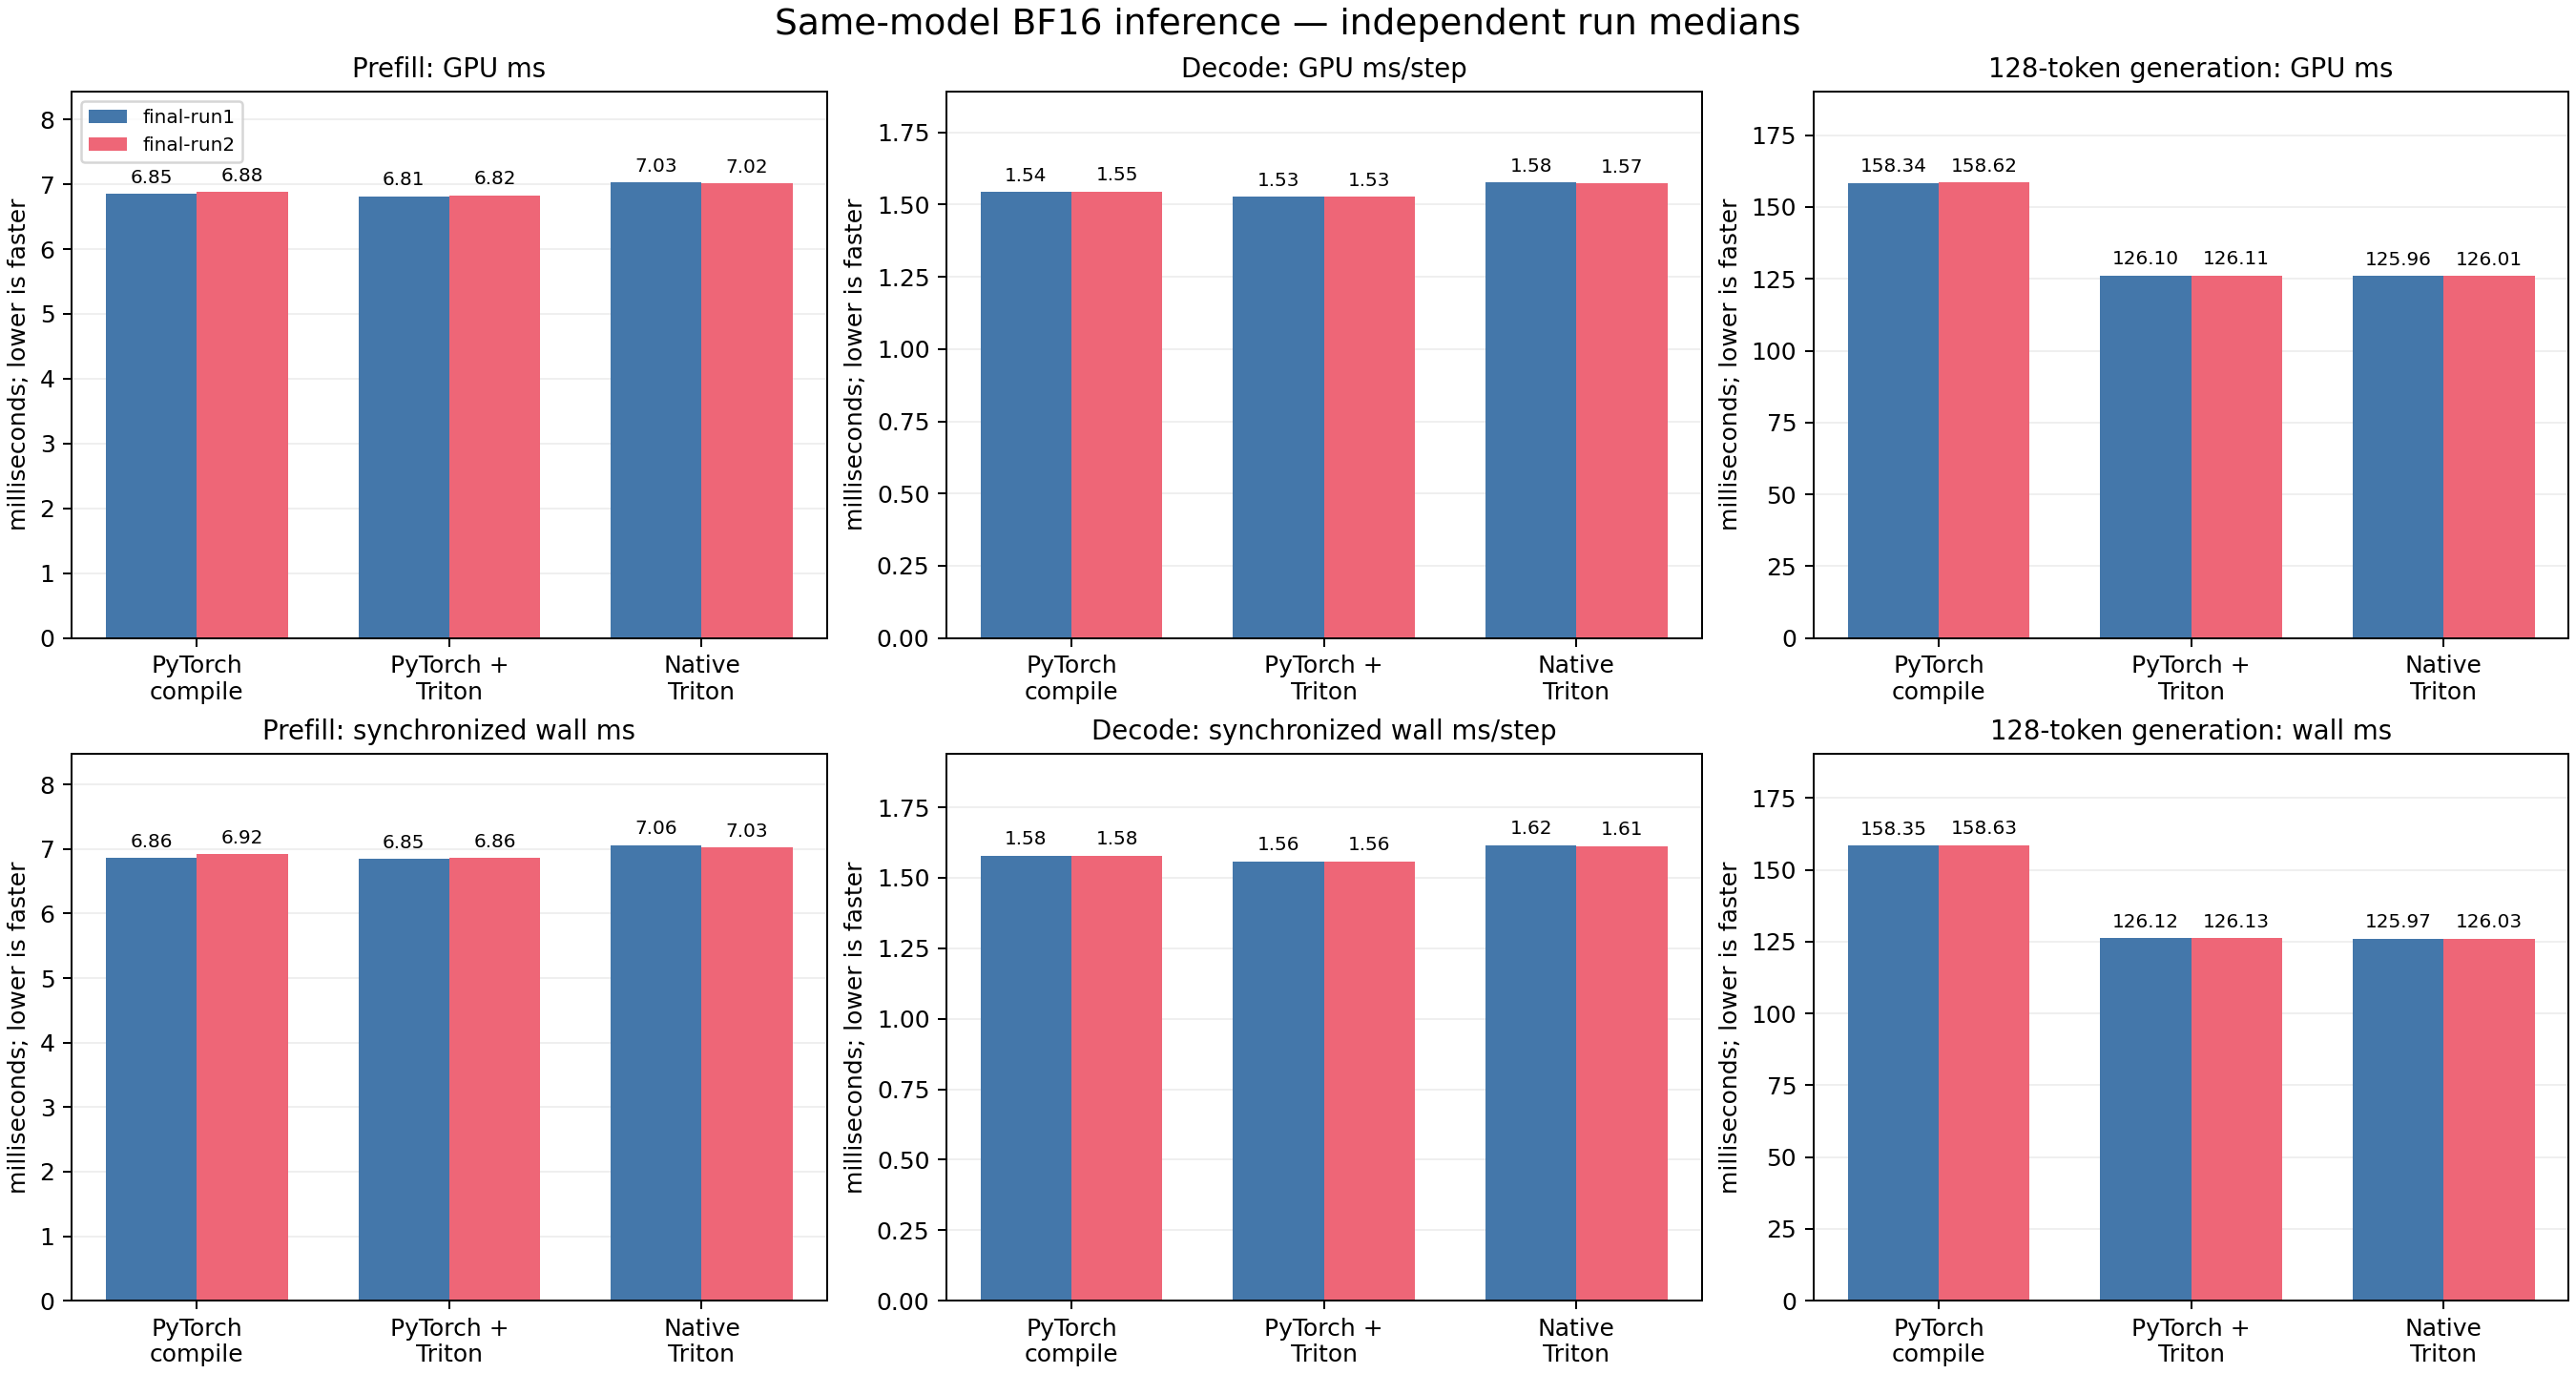

In [4]:
chart_path = RESULTS_DIR / 'charts.png'
plot_records(records, chart_path)
display(Image(filename=str(chart_path)))


In [5]:
# 표본과 실행별 정밀 수치를 보존합니다. 결과를 합쳐 표본 수를 늘리지 않습니다.
import csv
csv_path = RESULTS_DIR / 'summary.csv'
with csv_path.open('w', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(records[0]))
    writer.writeheader()
    writer.writerows(records)
print('CSV:', csv_path)
print('결과 JSON:', RESULTS_DIR)
print('수치 행:', len(records))


CSV: /content/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final/summary.csv
결과 JSON: /content/tensor2silicon_benchmark_reproduction/llm_bench/results/embedded-final
수치 행: 72
